<a href="https://colab.research.google.com/github/AliffiaHumrh/2311531004_AliffiaHumairah_ImageProcessing/blob/main/ImageProcessing_Tugas2_Aliffia_Humairah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install library
!pip install opencv-python-headless matplotlib numpy -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display

**Penjelasan:**

*   opencv-python-headless: Library utama untuk pemrosesan citra (image processing), seperti membaca gambar, resize, dan operasi pixel-wise
*   matplotlib: Untuk plot/visualisasi gambar hasil.
*   numpy: Untuk operasi matriks/array (citra digital adalah array 2D seperti di slide matriks f(x,y)).
*   import cv2: Impor OpenCV untuk fungsi seperti cv2.imread (baca gambar), cv2.resize, cv2.circle (buat pola), cv2.GaussianBlur (blur untuk simulasi noise), dan cv2.absdiff (fungsi built-in untuk absolute difference).
*   import numpy as np: NumPy untuk array (citra grayscale adalah array 2D uint8, nilai 0-255 seperti graylevel di slide).
*   import matplotlib.pyplot as plt: Untuk plot gambar dengan plt.imshow dan plt.subplot.
*   from google.colab import files: Untuk upload file gambar di Colab via files.upload().
*   from IPython.display import display: Untuk tampilkan output interaktif.




In [ ]:
# Fungsi pengurangan citra (support clip, abs, norm)
def subtract_images(img1, img2, mode='clip'):
    if img1.shape != img2.shape:
        h, w = min(img1.shape[0], img2.shape[0]), min(img1.shape[1], img2.shape[1])
        img1 = cv2.resize(img1, (w, h))
        img2 = cv2.resize(img2, (w, h))
        print(f"→ Ukuran gambar disesuaikan ke {h}x{w}")

    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    result = img1 - img2

    if mode == 'clip':
        result = np.clip(result, 0, 255)
    elif mode == 'abs':
        result = np.abs(result)
        result = np.clip(result, 0, 255)
    elif mode == 'norm':
        result = result - result.min()
        if result.max() > 0:
            result = 255 * (result / result.max())
    else:
        raise ValueError("Mode: 'clip', 'abs', atau 'norm'")

    return result.astype(np.uint8)

**Penjelasan:**



*   Parameter: img1 dan img2 adalah array citra (matriks NumPy). mode default 'clip' untuk pilih handling hasil pengurangan.
*   Cek ukuran: if img1.shape != img2.shape: Pastikan resolusi sama (M x N seperti di slide). Jika beda, resize ke ukuran terkecil pakai cv2.resize (interpolasi default bilinear). Ini penting karena operasi pixel-wise butuh posisi (i,j) selaras.
*   Konversi tipe: astype(np.float32): Ubah ke float untuk hindari overflow/underflow saat kurang (uint8 hanya 0-255, kurang bisa negatif).v
*   Operasi pengurangan: result = img1 - img2: Pixel-wise subtraction, sesuai rumus f(x,y) baru = img1(x,y) - img2(x,y). Ini langsung karena NumPy support broadcasting.
*   'clip': np.clip(result, 0, 255): Potong nilai <0 jadi 0, >255 jadi 255. Berguna untuk deteksi perubahan satu arah (misal brighter areas).
*   'abs': np.abs(result) lalu clip: Ambil nilai absolut |img1 - img2|, cocok untuk deteksi perbedaan tanpa arah
*   'norm': Shift ke positif (- result.min()), lalu skala ke 0-255 (255 * (result / result.max())). Ini enhansi kontras, mirip normalisasi intensitas setelah quantization.




Upload 2 gambar (yang mirip tapi ada perbedaan, misal: foto ruangan sama, satu ada orang)


Saving gambar9.png to gambar9 (2).png
Saving gambar10.png to gambar10 (2).png


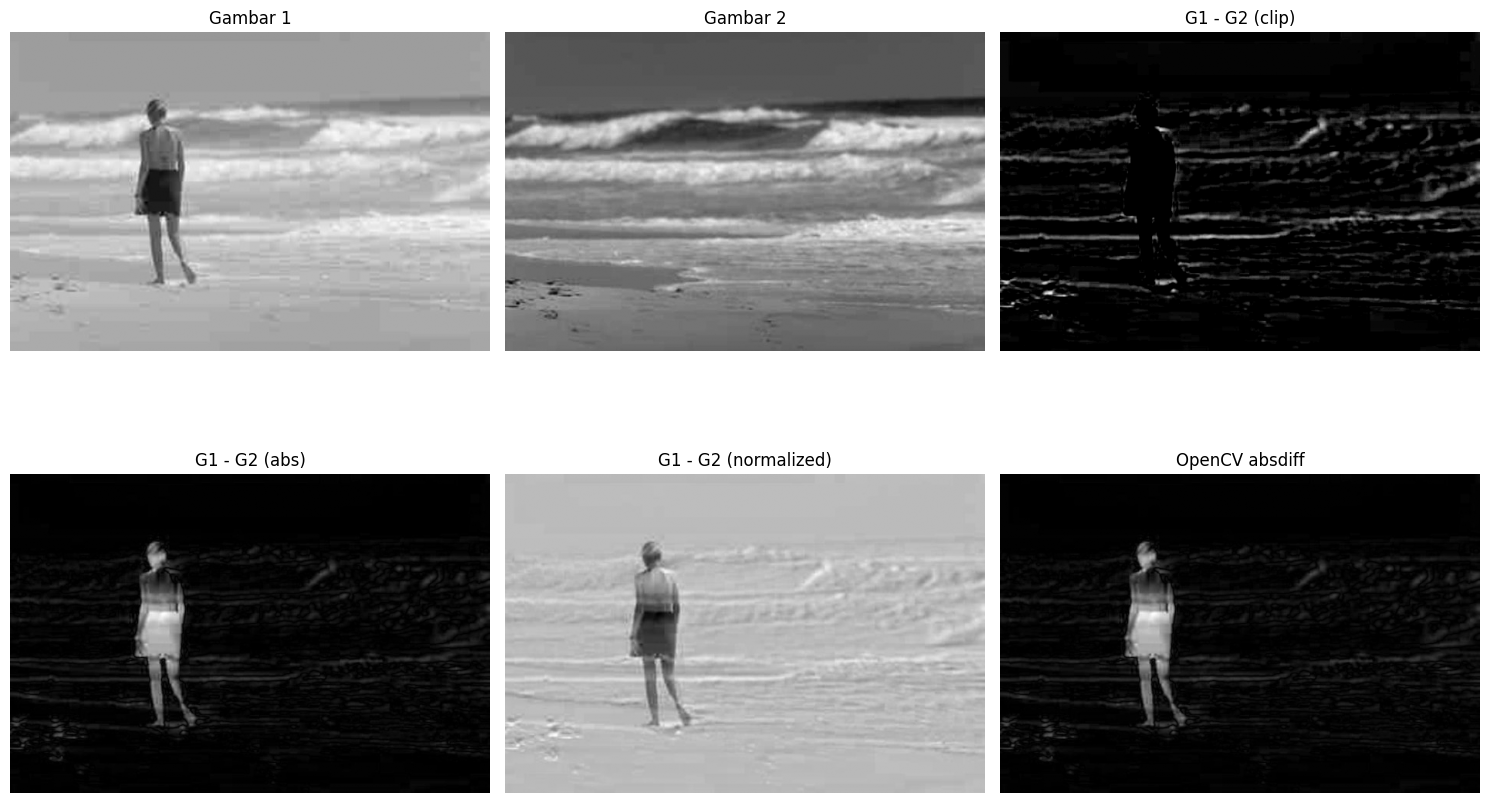

In [ ]:
print("Upload 2 gambar (yang mirip tapi ada perbedaan, misal: foto ruangan sama, satu ada orang)")
uploaded = files.upload()

if len(uploaded) >= 2:
    filenames = list(uploaded.keys())
    file1, file2 = filenames[0], filenames[1]

    imgA = cv2.imread(file1, cv2.IMREAD_GRAYSCALE)
    imgB = cv2.imread(file2, cv2.IMREAD_GRAYSCALE)

    if imgA is None or imgB is None:
        print("Gagal baca salah satu gambar!")
    else:
        result_clip = subtract_images(imgA, imgB, mode='clip')
        result_abs  = subtract_images(imgA, imgB, mode='abs')
        result_norm = subtract_images(imgA, imgB, mode='norm')

        plt.figure(figsize=(15, 10))
        plt.subplot(231); plt.imshow(imgA, cmap='gray'); plt.title('Gambar 1'); plt.axis('off')
        plt.subplot(232); plt.imshow(imgB, cmap='gray'); plt.title('Gambar 2'); plt.axis('off')
        plt.subplot(233); plt.imshow(result_clip, cmap='gray'); plt.title('G1 - G2 (clip)'); plt.axis('off')
        plt.subplot(234); plt.imshow(result_abs, cmap='gray'); plt.title('G1 - G2 (abs)'); plt.axis('off')
        plt.subplot(235); plt.imshow(result_norm, cmap='gray'); plt.title('G1 - G2 (normalized)'); plt.axis('off')
        plt.subplot(236); plt.imshow(cv2.absdiff(imgA, imgB), cmap='gray'); plt.title('OpenCV absdiff'); plt.axis('off')
        plt.tight_layout()
        plt.show()

else:
    print("Upload minimal 2 gambar untuk lihat hasil asli ya :)")

Upload 2 gambar (yang mirip tapi ada perbedaan, misal: foto ruangan sama, satu ada orang)


Saving gambar5.jpg to gambar5.jpg
Saving gambar6.jpg to gambar6.jpg


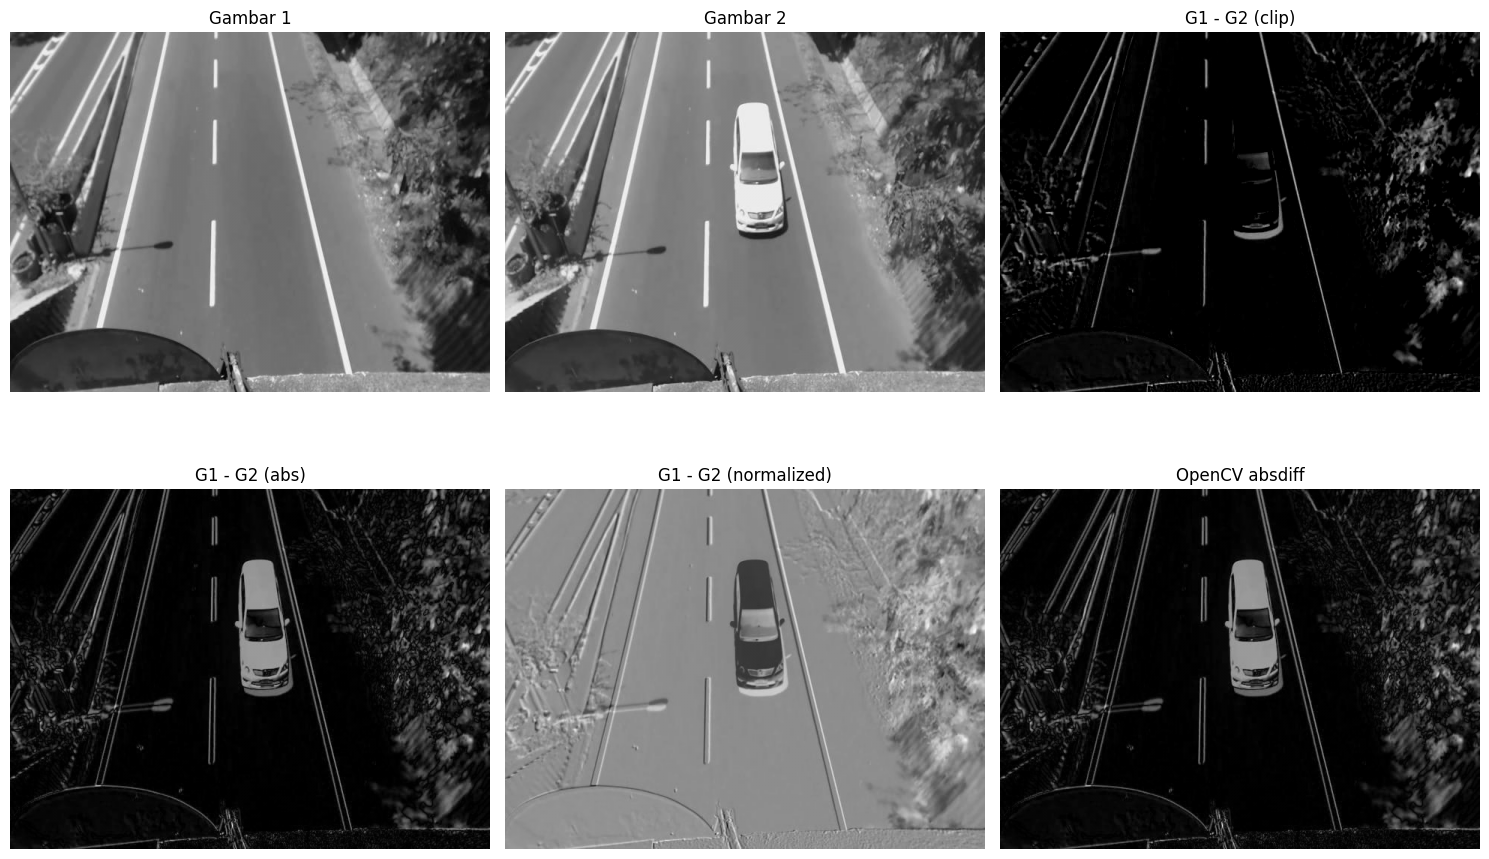

In [ ]:
print("Upload 2 gambar (yang mirip tapi ada perbedaan, misal: foto ruangan sama, satu ada orang)")
uploaded = files.upload()

if len(uploaded) >= 2:
    filenames = list(uploaded.keys())
    file1, file2 = filenames[0], filenames[1]

    imgA = cv2.imread(file1, cv2.IMREAD_GRAYSCALE)
    imgB = cv2.imread(file2, cv2.IMREAD_GRAYSCALE)

    if imgA is None or imgB is None:
        print("Gagal baca salah satu gambar!")
    else:
        result_clip = subtract_images(imgA, imgB, mode='clip')
        result_abs  = subtract_images(imgA, imgB, mode='abs')
        result_norm = subtract_images(imgA, imgB, mode='norm')

        plt.figure(figsize=(15, 10))
        plt.subplot(231); plt.imshow(imgA, cmap='gray'); plt.title('Gambar 1'); plt.axis('off')
        plt.subplot(232); plt.imshow(imgB, cmap='gray'); plt.title('Gambar 2'); plt.axis('off')
        plt.subplot(233); plt.imshow(result_clip, cmap='gray'); plt.title('G1 - G2 (clip)'); plt.axis('off')
        plt.subplot(234); plt.imshow(result_abs, cmap='gray'); plt.title('G1 - G2 (abs)'); plt.axis('off')
        plt.subplot(235); plt.imshow(result_norm, cmap='gray'); plt.title('G1 - G2 (normalized)'); plt.axis('off')
        plt.subplot(236); plt.imshow(cv2.absdiff(imgA, imgB), cmap='gray'); plt.title('OpenCV absdiff'); plt.axis('off')
        plt.tight_layout()
        plt.show()

else:
    print("Upload minimal 2 gambar untuk lihat hasil asli ya :)")

**Penjelasan:**



*   files.upload(): Buka dialog upload, simpan di dict uploaded.
*   Cek if len(uploaded) >= 2: Ambil dua file pertama.
*   cv2.imread(..., cv2.IMREAD_GRAYSCALE): Baca gambar sebagai grayscale (array 2D, sesuai slide graylevel).
*   Jika gagal baca (None), print error.
*   Hitung tiga mode: clip, abs, norm.
*   Visualisasi: Bagi jadi 2 baris 3 kolom (231=baris2 kolom1 dst.), tampilkan input dan hasil. Tambah cv2.absdiff sebagai benchmark (fungsi OpenCV untuk |imgA - imgB|).

**Hasil:**
1.   Clip (G1 - G2 (clip))
      
      Area di mana G1 lebih terang dari G2: putih/cerah (misalnya badan wanita dan pasir di depan). Area di mana G1 lebih gelap (ombak yang bergerak): hitam pekat (karena negatif → 0).
2.   Abs (G1 - G2 (abs))

      Semua perbedaan (mau lebih terang atau lebih gelap) jadi positif: muncul putih/cerah.
3.   Normalized (G1 - G2 (normalized))

      Memperbesar kontras perbedaan kecil. Area yang hampir sama jadi hampir hitam, perbedaan kecil jadi lebih terlihat.
4.  OpenCV absdiff

    Sama persis dengan mode 'abs' di kode (fungsi built-in cv2.absdiff(img1, img2))